In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [3]:
from sklearn.datasets import load_iris

In [4]:
iris = load_iris()

In [5]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [9]:
# Independent feature
X=pd.DataFrame(iris['data'], columns=['sepal length in cm','sepal width','petal length','petal width'])

In [7]:
#Dependent feature
y=iris['target']

In [10]:
# Train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=10)

In [18]:
# Apply decission tree classifier
from sklearn.tree import DecisionTreeClassifier
tressClassifier = DecisionTreeClassifier(max_depth=2)

In [19]:
tressClassifier.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=2)

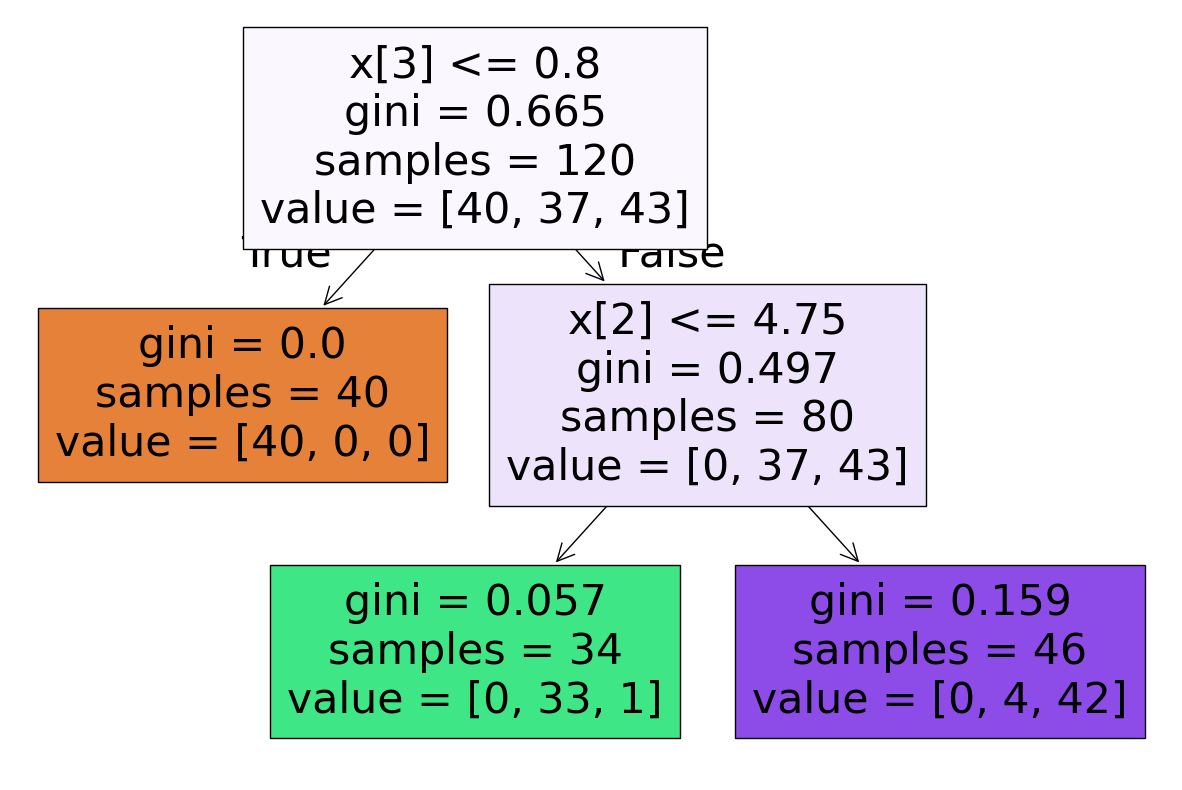

In [20]:
# Visualize the DT
plt.figure(figsize=(15,10))
tree.plot_tree(tressClassifier, filled=True)
plt.show()

In [22]:
y_pred = tressClassifier.predict(X_test)

In [23]:
from sklearn.metrics import confusion_matrix, classification_report

In [24]:
cm = confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

[[10  0  0]
 [ 0 11  2]
 [ 0  0  7]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.85      0.92        13
           2       0.78      1.00      0.88         7

    accuracy                           0.93        30
   macro avg       0.93      0.95      0.93        30
weighted avg       0.95      0.93      0.93        30



Decission Tree CLassifier prepruning and hyperparameter tuning

In [25]:
params={
    'criterion':['gini','entropy','log_loss'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5],
    'max_features':['auto','sqrt','log2']
}

In [26]:
params

{'criterion': ['gini', 'entropy', 'log_loss'],
 'splitter': ['best', 'random'],
 'max_depth': [1, 2, 3, 4, 5],
 'max_features': ['auto', 'sqrt', 'log2']}

In [27]:
from sklearn.model_selection import GridSearchCV

In [30]:
treemodel = DecisionTreeClassifier()

In [33]:
grid = GridSearchCV(tressClassifier,param_grid=params,cv=5,scoring='accuracy')

In [34]:
import warnings
warnings.filterwarnings('ignore')
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(max_depth=2),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 2, 3, 4, 5],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [35]:
grid.best_params_

{'criterion': 'entropy',
 'max_depth': 2,
 'max_features': 'sqrt',
 'splitter': 'best'}

In [36]:
grid.best_score_

np.float64(0.95)

In [37]:
y_pred = grid.predict(X_test)

In [39]:
y_pred

array([1, 2, 0, 1, 0, 1, 2, 1, 0, 1, 1, 2, 1, 0, 0, 2, 1, 0, 0, 0, 2, 2,
       2, 0, 1, 0, 1, 1, 2, 2])

In [40]:
cm = confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

[[10  0  0]
 [ 0 11  2]
 [ 0  0  7]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.85      0.92        13
           2       0.78      1.00      0.88         7

    accuracy                           0.93        30
   macro avg       0.93      0.95      0.93        30
weighted avg       0.95      0.93      0.93        30



In [42]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_test,y_pred)
score

0.9333333333333333

Diabetes Predication

In [43]:
from sklearn.datasets import load_diabetes


In [45]:
datasets = load_diabetes()

In [47]:
print(datasets['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [48]:
datasets

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [52]:
import pandas as pd
df_diabetes = pd.DataFrame(datasets.data, columns=['age','sex',
  'bmi',
  'bp',
  's1',
  's2',
  's3',
  's4',
  's5',
  's6'])
df_diabetes.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [54]:
# Independent and dependent feature
X=df_diabetes
y=datasets['target']

In [56]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3, random_state=40)

In [57]:
X_train.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
161,-0.045472,0.050680,0.063852,0.070072,0.133274,0.131461,-0.039719,0.108111,0.075741,0.085907
27,-0.023677,-0.044642,0.059541,-0.040099,-0.042848,-0.043589,0.011824,-0.039493,-0.015999,0.040343
149,-0.049105,0.050680,-0.005128,-0.046985,-0.020832,-0.020416,-0.069172,0.071210,0.061238,-0.038357
188,0.005383,-0.044642,-0.002973,0.049415,0.074108,0.070710,0.044958,-0.002592,-0.001496,-0.009362
246,0.041708,-0.044642,-0.032073,-0.061892,0.079612,0.050982,0.056003,-0.009972,0.045067,-0.059067


In [58]:
X_train.corr()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.141301,0.234150,0.332892,0.285592,0.260704,-0.095826,0.241654,0.282784,0.323534
sex,0.141301,1.000000,0.103081,0.217275,0.002696,0.124169,-0.383618,0.336603,0.128841,0.263595
bmi,0.234150,0.103081,1.000000,0.484194,0.263851,0.281320,-0.331715,0.391250,0.426544,0.373092
bp,0.332892,0.217275,0.484194,1.000000,0.272348,0.216771,-0.171849,0.275347,0.420387,0.478257
s1,0.285592,0.002696,0.263851,0.272348,1.000000,0.898255,0.099838,0.514499,0.507038,0.319552
s2,0.260704,0.124169,0.281320,0.216771,0.898255,1.000000,-0.174089,0.670592,0.317096,0.305478
s3,-0.095826,-0.383618,-0.331715,-0.171849,0.099838,-0.174089,1.000000,-0.732113,-0.344825,-0.249945
s4,0.241654,0.336603,0.391250,0.275347,0.514499,0.670592,-0.732113,1.000000,0.562816,0.390806
s5,0.282784,0.128841,0.426544,0.420387,0.507038,0.317096,-0.344825,0.562816,1.000000,0.424126
s6,0.323534,0.263595,0.373092,0.478257,0.319552,0.305478,-0.249945,0.390806,0.424126,1.000000


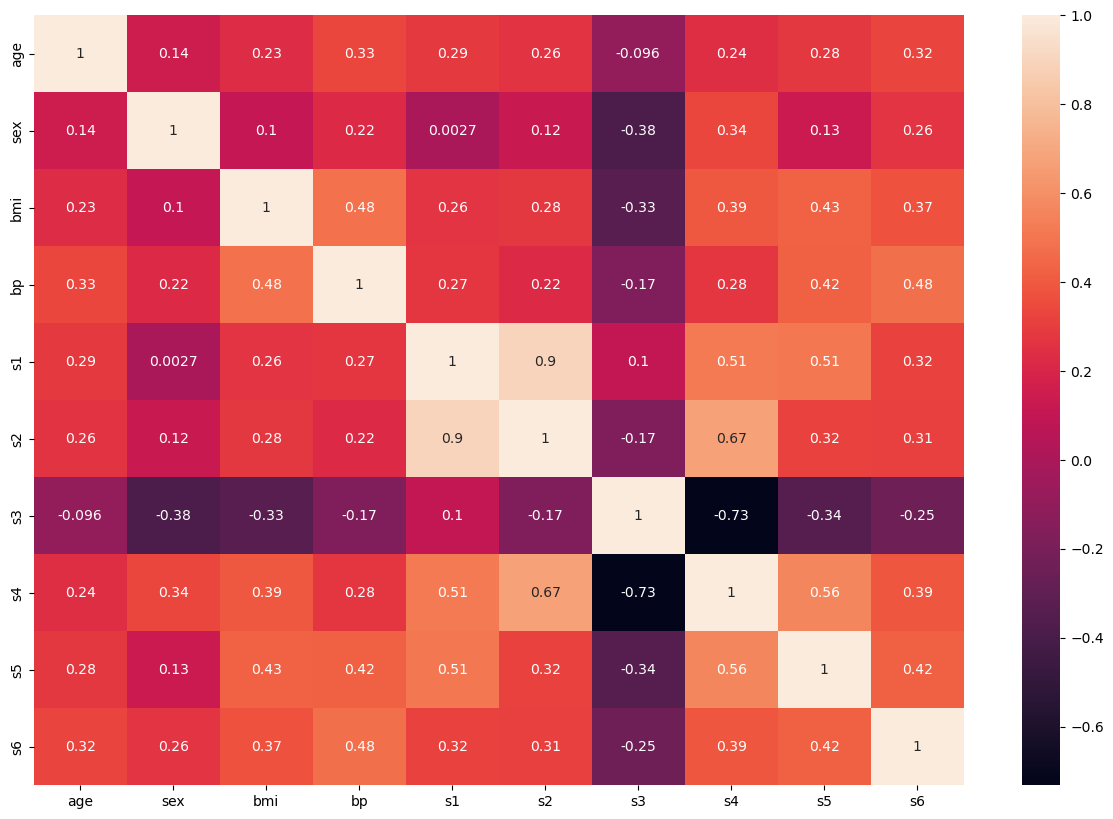

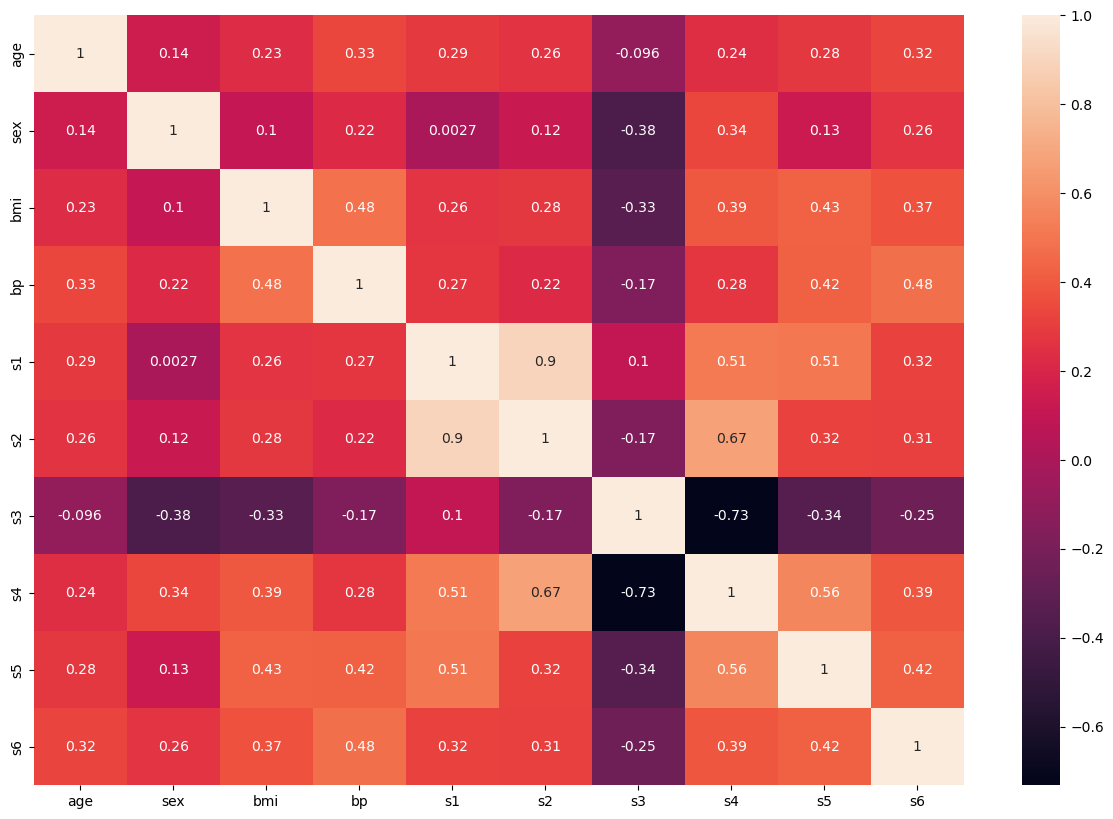

In [60]:
import seaborn as sns
plt.figure(figsize=(15,10))
sns.heatmap(X_train.corr(),annot=True)
plt.show()

In [61]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor()
regressor.fit(X_train,y_train)

DecisionTreeRegressor()

Hyperparameter tuning

In [62]:
params={
    'criterion':['squared_error','friedman_mse','absolute_error'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5,10,15,20,25],
    'max_features':['auto','sqrt','log2']
}

In [63]:
from sklearn.model_selection import GridSearchCV

In [66]:
regressor = DecisionTreeRegressor()

In [69]:
grid = GridSearchCV(regressor,param_grid=params,cv=5,scoring='neg_mean_squared_error')

In [70]:
import warnings
warnings.filterwarnings('ignore')
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error'],
                         'max_depth': [1, 2, 3, 4, 5, 10, 15, 20, 25],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='neg_mean_squared_error')

In [73]:
grid.best_params_

{'criterion': 'squared_error',
 'max_depth': 2,
 'max_features': 'log2',
 'splitter': 'best'}

In [75]:
#Predications
y_pred = grid.predict(X_test)

In [76]:
y_pred

array([ 90.9673913 , 140.09259259, 211.0375    , 211.0375    ,
       211.0375    , 211.0375    , 140.09259259,  90.9673913 ,
       140.09259259, 140.09259259, 211.0375    , 140.09259259,
        90.9673913 , 140.09259259, 140.09259259,  90.9673913 ,
       140.09259259,  90.9673913 ,  90.9673913 ,  90.9673913 ,
        90.9673913 , 211.0375    , 140.09259259,  90.9673913 ,
       140.09259259, 140.09259259, 180.24137931,  90.9673913 ,
       140.09259259,  90.9673913 , 211.0375    , 140.09259259,
       140.09259259, 140.09259259,  90.9673913 ,  90.9673913 ,
        90.9673913 ,  90.9673913 , 211.0375    , 140.09259259,
       140.09259259,  90.9673913 ,  90.9673913 , 140.09259259,
       211.0375    , 140.09259259,  90.9673913 , 140.09259259,
       140.09259259, 211.0375    , 180.24137931, 211.0375    ,
       211.0375    , 211.0375    ,  90.9673913 , 180.24137931,
       140.09259259, 211.0375    ,  90.9673913 , 140.09259259,
       140.09259259,  90.9673913 , 211.0375    , 211.03

In [78]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [79]:
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.22471040123641584
55.00895846980436
4780.236156775425


In [82]:
# If you want to see how your DT looks
selectedmodel = DecisionTreeRegressor(criterion='friedman_mse',max_depth=4,max_features='log2',splitter='best')

In [83]:
selectedmodel.fit(X_train,y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=4,
                      max_features='log2')

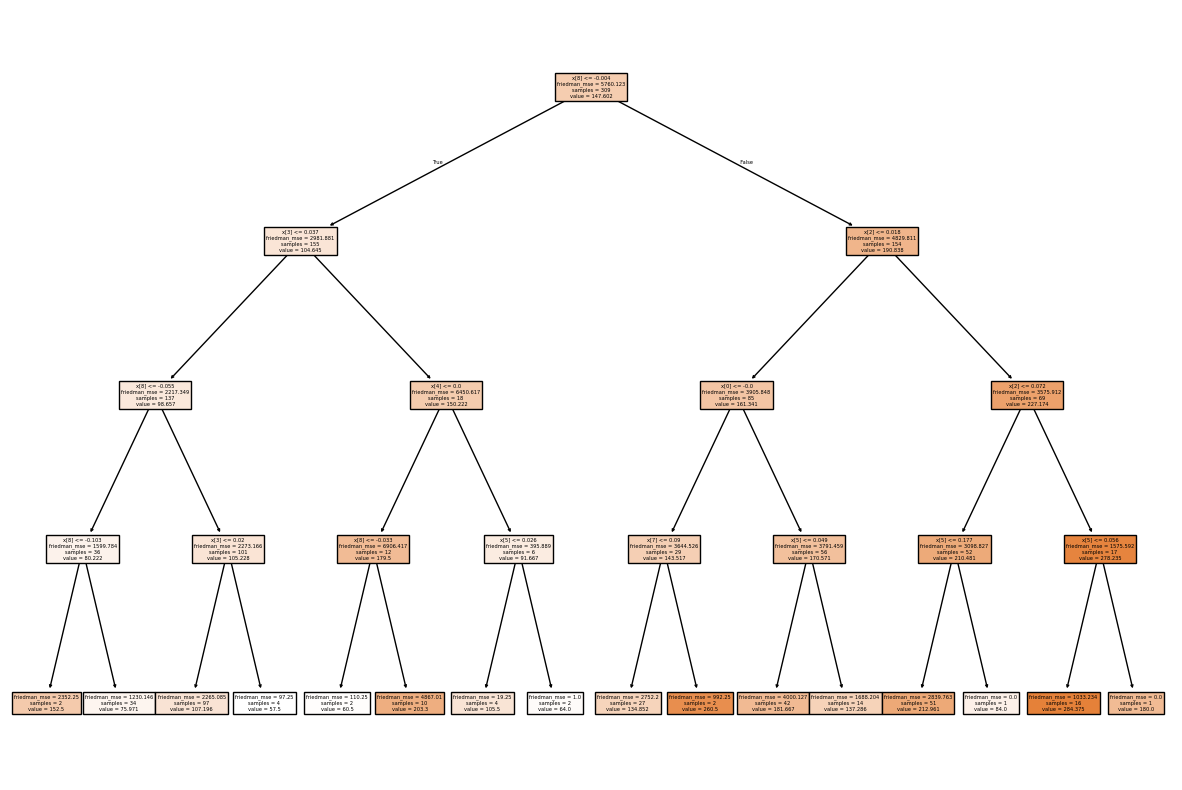

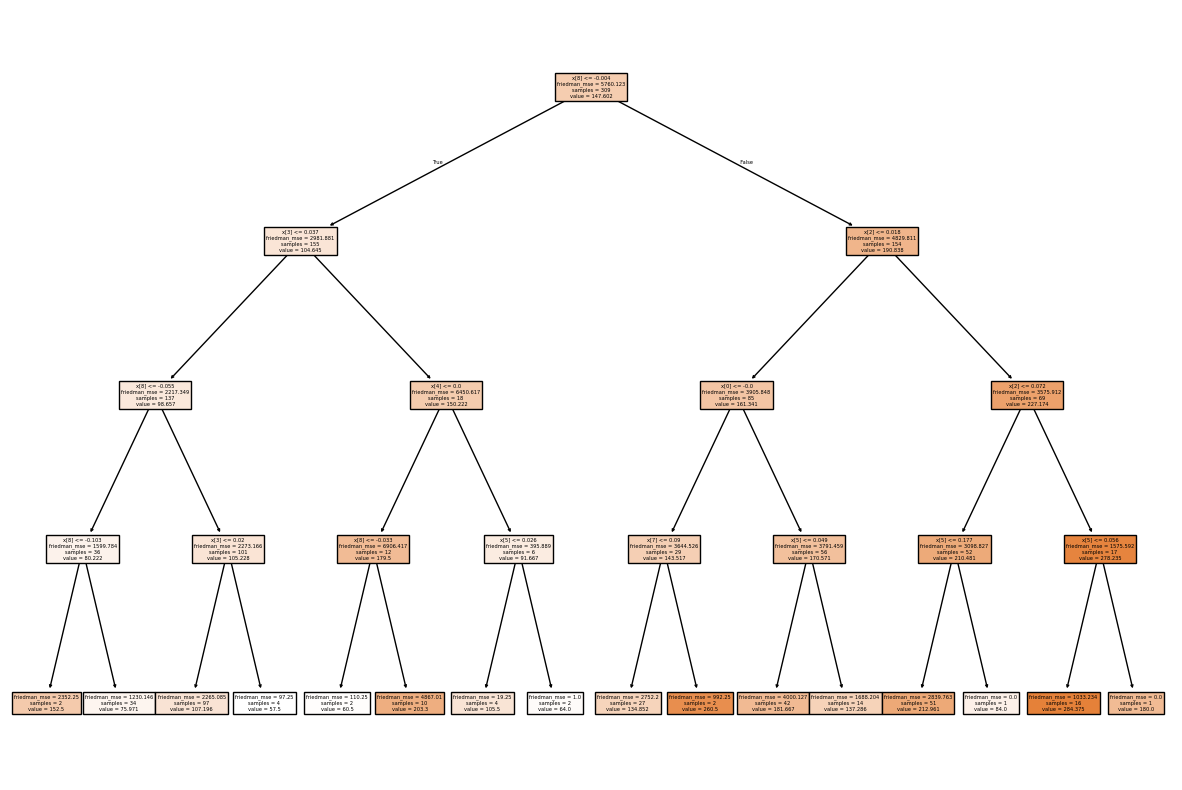

In [85]:
# Visualize the DT
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(selectedmodel, filled=True)
plt.show()